<a href="https://colab.research.google.com/github/eman-cmd/NextGen-Retail-Banking-Intelligence/blob/main/Bank_Churn_Prediction_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
file_name = "/content/Bank Customer Churn Prediction.csv"
df = pd.read_csv(file_name)

# Display the dataset details
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\n--- Columns in this dataset ---")
print(df.columns.tolist())
print("\n--- First 3 rows ---")
df.head(3)


Dataset loaded successfully!
Dataset shape: (10000, 12)

--- Columns in this dataset ---
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

--- First 3 rows ---


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import warnings
warnings.filterwarnings('ignore') # Hides the SHAP numpy warning

# 1. Feature Engineering using the new column names
df['balance_to_salary_ratio'] = df['balance'] / (df['estimated_salary'] + 1)
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 65, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])

# 2. Separate into features (X) and target (y)
# Dropping customer identifiers and the target 'churn' column
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# 3. Define feature groups based on the actual dataset names
numeric_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_to_salary_ratio']
categorical_features = ['country', 'gender', 'age_group']

# 4. Stratified Split to maintain correct class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data preprocessing complete!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Data preprocessing complete!
Training features shape: (8000, 12)
Testing features shape: (2000, 12)


In [ ]:
# 1. Setup Preprocessor Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])



In [ ]:
# 2. Construct the Synthetic Oversampling + Classifier Pipeline
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

In [ ]:
# 2. Construct the Synthetic Oversampling + Classifier Pipeline
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

In [ ]:
# 4. Run Optimization Model
print("Running optimization grids on real data...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Configuration found: {grid_search.best_params_}")

Running optimization grids on real data...
Optimal Configuration found: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 150}


In [ ]:
# 1. Generate predictions using the optimal model configuration
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Print evaluation metrics
print("--- CLASSIFICATION METRICS (REAL DATA) ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")


--- CLASSIFICATION METRICS (REAL DATA) ---
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.59      0.64      0.61       407

    accuracy                           0.83      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.84      0.83      0.84      2000

ROC-AUC Score: 0.8518



Rendering SHAP Feature Explanations...


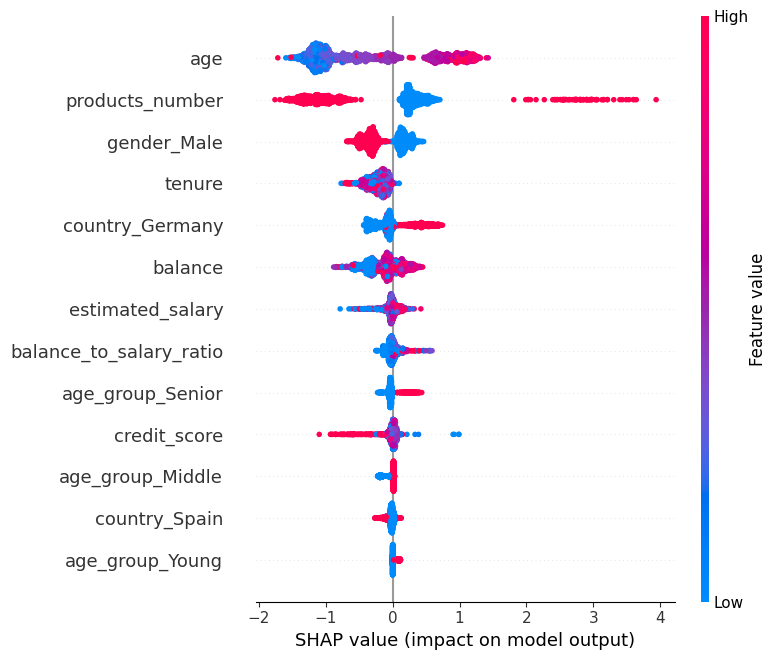

In [ ]:
# 1. Retrieve the encoded categorical column names from the pipeline
encoded_cat_features = best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_features)

# 2. Transform the test data to match what the XGBoost model expects
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

# 3. Initialize the tree explainer and calculate SHAP values
explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# 4. Generate the plot
print("Rendering SHAP Feature Explanations...")
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)
